# Thesis Experiment: GNN-Enhanced RL Gamma Controller
**Architecture:** GNN (Graph Neural Network) sebagai *feature extractor* → RL (PPO) sebagai *gamma controller* → Network-Regularized Markowitz sebagai *optimizer*.

**Inovasi:** Alih-alih menggunakan statistik makro sederhana (mean, std) sebagai observasi RL, kita menggunakan **embedding GNN** yang kaya akan informasi struktur graf relasi antar aset.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import warnings
import os
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from scipy.optimize import minimize
from scipy.linalg import eigh
from tqdm.notebook import tqdm

# PyTorch & PyTorch Geometric untuk GNN
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Libraries loaded. Device: {DEVICE}')


Libraries loaded. Device: cpu


## Phase 1: Data Preparation

In [2]:
file_old  = 'crypto_data_real.xlsx'
file_2024 = 'crypto_data_2024.xlsx'

def load_and_preprocess(f1, f2):
    r_old  = pd.read_excel(f1, sheet_name='Returns', index_col=0)
    r_2024 = pd.read_excel(f2, sheet_name='Returns', index_col=0)
    r_old.index  = pd.to_datetime(r_old.index)
    r_2024.index = pd.to_datetime(r_2024.index)
    assets = sorted(set(r_old.columns) & set(r_2024.columns))
    return r_old[assets], r_2024[assets], assets

ret_old, ret_2024, assets = load_and_preprocess(file_old, file_2024)
print(f'Data loaded. Assets: {len(assets)}, Train rows: {len(ret_old)}, Test rows: {len(ret_2024)}')


Data loaded. Assets: 10, Train rows: 763, Test rows: 365


## Phase 2: Core Portfolio Functions (RMT + Network Markowitz)

In [3]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    eigenvalues[eigenvalues < lambda_max] = np.mean(eigenvalues[eigenvalues < lambda_max])
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised

def get_centrality_weights(returns_window, gamma=1.0):
    T, N = returns_window.shape
    mu    = returns_window.mean().values
    sigma = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f
    cov_f += np.eye(N) * 1e-8
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    adj = np.maximum(0, 1 - dist_mat)
    G = nx.from_numpy_array(adj)
    try:
        centrality = nx.eigenvector_centrality(G, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(G).values()))
    fun  = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bnds = tuple((0, 1) for _ in range(N))
    res  = minimize(fun, np.ones(N)/N, method='SLSQP', bounds=bnds, constraints=cons)
    return res.x if res.success else np.ones(N)/N

class PortfolioStrategy:
    def __init__(self, name): self.name = name; self.last_gamma = 1.0
    def compute_weights(self, returns_window): raise NotImplementedError()

class EquallyWeighted(PortfolioStrategy):
    def compute_weights(self, w): return np.ones(w.shape[1]) / w.shape[1]

class ClassicalMarkowitz(PortfolioStrategy):
    def compute_weights(self, w):
        cov = w.cov().values
        inv_cov = np.linalg.pinv(cov)
        wt = np.clip(inv_cov @ np.ones(cov.shape[0]), 0, 1)
        return wt / np.sum(wt)

class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name, gamma=1.0): super().__init__(name); self.gamma = gamma
    def compute_weights(self, w): return get_centrality_weights(w, self.gamma)

print('Core functions loaded.')


Core functions loaded.


## Phase 3: GNN Feature Extractor
GNN dilatih secara *online* pada setiap jendela data untuk menghasilkan **node embeddings** yang merepresentasikan relasi struktural antar aset. Embeddings ini kemudian di-*aggregate* menjadi vektor observasi untuk RL.

In [4]:
class CorrelationGNN(nn.Module):
    """
    GNN untuk mengekstrak embedding relasi antar aset.
    Input: fitur node (mean, std, skew, kurt) per aset.
    Output: embedding per node → di-aggregate menjadi vektor observasi RL.
    """
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=8):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.output_dim = output_dim

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return x  # (N_assets, output_dim)

    def get_graph_embedding(self, x, edge_index):
        """Mean-pooling node embeddings → single graph embedding"""
        node_emb = self.forward(x, edge_index)
        return node_emb.mean(dim=0)  # (output_dim,)


def build_graph_data(returns_window, corr_threshold=0.3):
    """Membangun PyG Data dari window return"""
    n = returns_window.shape[1]
    feats = np.stack([
        returns_window.mean().values,
        returns_window.std().values,
        returns_window.skew().values,
        returns_window.kurtosis().values
    ], axis=1)  # (n, 4)
    x = torch.FloatTensor(feats).to(DEVICE)

    corr = returns_window.corr().values
    edges = []
    for i in range(n):
        for j in range(i+1, n):
            if abs(corr[i, j]) > corr_threshold:
                edges += [[i, j], [j, i]]
    if len(edges) == 0:
        # Fallback: fully connected
        edges = [[i, j] for i in range(n) for j in range(n) if i != j]
    edge_index = torch.LongTensor(edges).t().contiguous().to(DEVICE)
    y = torch.FloatTensor(corr).to(DEVICE)
    return Data(x=x, edge_index=edge_index, y=y)


def train_gnn_quick(returns_window, gnn_model, epochs=20, lr=0.01):
    """Melatih GNN secara cepat pada satu window"""
    data = build_graph_data(returns_window)
    optimizer = torch.optim.Adam(gnn_model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    gnn_model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        emb = gnn_model(data.x, data.edge_index)
        # Rekonstruksi korelasi via cosine similarity
        norm = F.normalize(emb, dim=1)
        pred_corr = norm @ norm.t()
        loss = criterion(pred_corr, data.y)
        loss.backward()
        optimizer.step()
    return gnn_model, data


GNN_OUTPUT_DIM = 8
print(f'GNN architecture defined. Embedding dim: {GNN_OUTPUT_DIM}')


GNN architecture defined. Embedding dim: 8


## Phase 4: GNN-Enhanced RL Environment
**Observasi RL** = *Graph embedding* (GNN output) + statistik dasar pasar, jauh lebih kaya dari sebelumnya.

In [5]:
GNN_OBS_DIM = GNN_OUTPUT_DIM + 4  # GNN embedding + (mean, std, corr, std_cent)

class GNNGammaEnv(gym.Env):
    """
    Environment RL dengan observasi berbasis GNN embedding.
    Action: gamma (0.1 – 10.0)
    Observation: [gnn_embedding (8) | mean, std, corr, std_cent (4)]
    """
    def __init__(self, returns_data, window_size=120, reward_mode='sharpe',
                 gnn_epochs=15, retrain_gnn_every=7):
        super().__init__()
        self.data           = returns_data
        self.window_size    = window_size
        self.reward_mode    = reward_mode
        self.gnn_epochs     = gnn_epochs
        self.retrain_every  = retrain_gnn_every
        self.current_step   = window_size
        self.action_space   = spaces.Box(low=0.1, high=10.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(GNN_OBS_DIM,), dtype=np.float32)
        self.port_val  = 1.0
        self.peak_val  = 1.0
        # GNN state
        self.gnn = CorrelationGNN(input_dim=4, hidden_dim=16, output_dim=GNN_OUTPUT_DIM).to(DEVICE)
        self._cached_gnn_emb = np.zeros(GNN_OUTPUT_DIM, dtype=np.float32)
        self._steps_since_gnn_retrain = 0

    def _get_window(self):
        return self.data.iloc[self.current_step - self.window_size : self.current_step]

    def _update_gnn_embedding(self):
        win = self._get_window()
        self.gnn, data = train_gnn_quick(win, self.gnn, epochs=self.gnn_epochs)
        self.gnn.eval()
        with torch.no_grad():
            emb = self.gnn.get_graph_embedding(data.x, data.edge_index)
        self._cached_gnn_emb = emb.cpu().numpy().astype(np.float32)
        self._steps_since_gnn_retrain = 0

    def _get_obs(self):
        win = self._get_window()
        # Retrain GNN setiap N langkah
        if self._steps_since_gnn_retrain % self.retrain_every == 0:
            self._update_gnn_embedding()
        self._steps_since_gnn_retrain += 1
        # Statistik dasar
        m    = float(win.mean().mean() * 100)
        s    = float(win.std().mean()  * 100)
        c    = float(win.corr().values.mean())
        st_c = float(np.std(get_centrality_weights(win)) * 10)
        basic = np.array([m, s, c, st_c], dtype=np.float32)
        return np.concatenate([self._cached_gnn_emb, basic])

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val = 1.0
        self.peak_val = 1.0
        self._steps_since_gnn_retrain = 0
        return self._get_obs(), {}

    def step(self, action):
        win = self._get_window()
        w   = get_centrality_weights(win, float(action[0]))
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)
        drawdown  = (self.port_val - self.peak_val) / self.peak_val
        ew_ret    = self.data.iloc[self.current_step].mean()
        if self.reward_mode == 'raw_return':    reward = port_ret
        elif self.reward_mode == 'excess_return': reward = port_ret - ew_ret
        elif self.reward_mode == 'defensive':    reward = port_ret - 2.0 * abs(drawdown)
        else:                                    reward = port_ret / (win.values.std() + 1e-6)
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        return self._get_obs(), reward, done, False, {}


# ─── Strategi RL yang menggunakan GNN-trained model ──────────────────
class GNNRLNetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name, model_path):
        super().__init__(name)
        self.model = PPO.load(model_path)
        self.gnn   = CorrelationGNN(input_dim=4, hidden_dim=16, output_dim=GNN_OUTPUT_DIM).to(DEVICE)

    def _get_gnn_embedding(self, returns_window):
        _, data = train_gnn_quick(returns_window, self.gnn, epochs=10)
        self.gnn.eval()
        with torch.no_grad():
            emb = self.gnn.get_graph_embedding(data.x, data.edge_index)
        return emb.cpu().numpy().astype(np.float32)

    def compute_weights(self, returns_window):
        gnn_emb = self._get_gnn_embedding(returns_window)
        m    = float(returns_window.mean().mean() * 100)
        s    = float(returns_window.std().mean()  * 100)
        c    = float(returns_window.corr().values.mean())
        st_c = float(np.std(get_centrality_weights(returns_window)) * 10)
        basic = np.array([m, s, c, st_c], dtype=np.float32)
        obs = np.concatenate([gnn_emb, basic])
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(action[0])
        return get_centrality_weights(returns_window, gamma=self.last_gamma)

print('GNN-RL Environment defined. Observation dim:', GNN_OBS_DIM)


GNN-RL Environment defined. Observation dim: 12


## Phase 5: Backtest Engine

In [6]:
def run_backtest_with_frequency(strategy, data, window=120, rebalance_freq=7):
    rets, dates, weights_history, gamma_history = [], [], [], []
    current_weights = None
    current_gamma   = 1.0
    print(f'Processing {strategy.name} (freq={rebalance_freq}d)...')
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df = data.iloc[i-window:i]
            current_weights = strategy.compute_weights(window_df)
            current_gamma   = getattr(strategy, 'last_gamma', 1.0)
        r = np.dot(current_weights, data.iloc[i].values)
        rets.append(r)
        dates.append(data.index[i])
        weights_history.append(current_weights)
        gamma_history.append(current_gamma)
    return (
        pd.Series(rets, index=dates),
        pd.DataFrame(weights_history, index=dates, columns=data.columns),
        pd.Series(gamma_history, index=dates)
    )

def calculate_metrics(r):
    cr = (1+r).cumprod()
    sharpe = (np.mean(r)/np.std(r))*np.sqrt(252)
    mdd = ((cr/cr.expanding().max())-1).min()
    return {'Total Return': f'{cr.iloc[-1]-1:.2%}', 'Sharpe': f'{sharpe:.2f}', 'MDD': f'{mdd:.2%}'}

print('Backtest engine ready.')


Backtest engine ready.


## Phase 6: Training GNN-RL Models + Comparative Backtest
> ⚠️ Training GNN+RL lebih lambat dari RL polos karena setiap step melatih GNN.
> Gunakan `STEPS = 10000` dulu untuk uji coba cepat, lalu naikkan ke 50000 untuk thesis final.

Training GNN-RL models (10,000 steps)...


GNN-RL (Sharpe):   0%|          | 0/10000 [00:00<?, ?it/s]

GNN-RL (Defensive):   0%|          | 0/10000 [00:00<?, ?it/s]

GNN-RL (Excess):   0%|          | 0/10000 [00:00<?, ?it/s]

Processing NW (Gamma=1.0) (freq=7d)...
Processing NW (Gamma=0.5) (freq=7d)...
Processing EW (1/N) (freq=7d)...
Processing Markowitz (MVP) (freq=7d)...
Processing GNN-RL (Sharpe) (freq=7d)...
Processing GNN-RL (Defensive) (freq=7d)...
Processing GNN-RL (Excess) (freq=7d)...


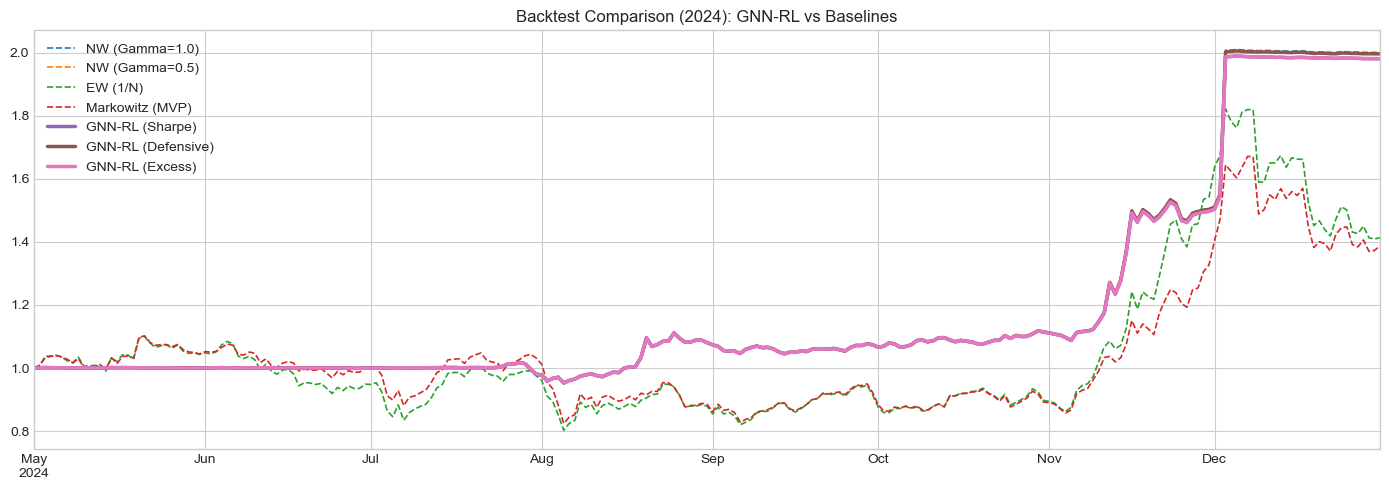

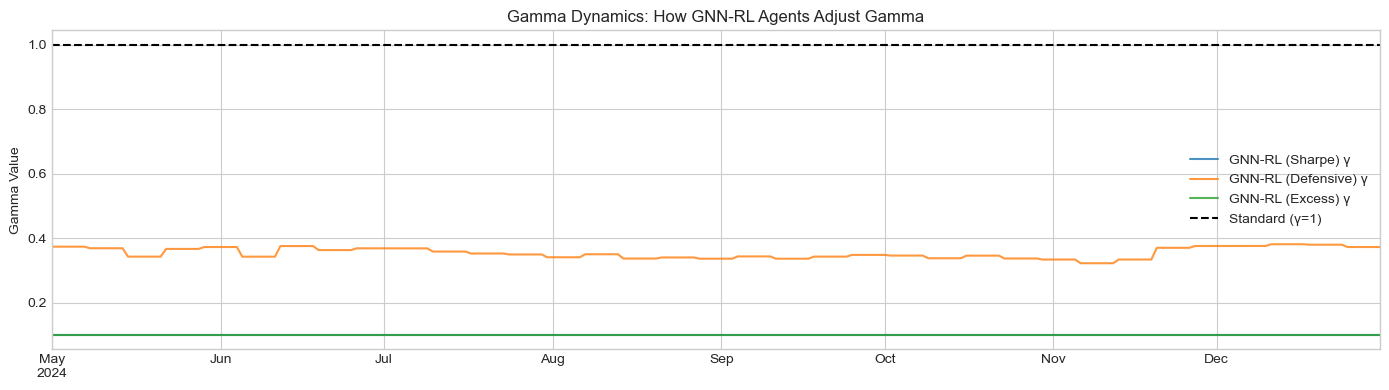


=== Performance Metrics ===
                   Total Return Sharpe      MDD
NW (Gamma=1.0)          100.07%   2.17   -6.40%
NW (Gamma=0.5)           99.83%   2.17   -6.39%
EW (1/N)                 41.30%   1.06  -27.04%
Markowitz (MVP)          38.77%   1.06  -25.23%
GNN-RL (Sharpe)          98.07%   2.17   -6.37%
GNN-RL (Defensive)       99.61%   2.17   -6.39%
GNN-RL (Excess)          98.07%   2.17   -6.37%


In [7]:
# ─── Progress Bar Callback ───────────────────────────────────────────
class TqdmCallback(BaseCallback):
    def __init__(self, total_timesteps, desc='Training'):
        super().__init__()
        self.pbar = None
        self.total_timesteps = total_timesteps
        self.desc = desc
    def _on_training_start(self):
        self.pbar = tqdm(total=self.total_timesteps, desc=self.desc)
    def _on_step(self):
        self.pbar.update(1)
        return True
    def _on_training_end(self):
        if self.pbar: self.pbar.close()

# ─── Konfigurasi ─────────────────────────────────────────────────────
SET_WINDOW    = 120
SET_REBALANCE = 7
STEPS         = 10000   # Naikkan ke 50000 untuk thesis final
train_data = ret_old.iloc[:int(len(ret_old)*0.8)]

def train_gnn_rl_model(env, name, desc='Training'):
    model = PPO(
        'MlpPolicy', env,
        learning_rate=0.0001,
        n_steps=2048,
        batch_size=64,
        ent_coef=0.01,
        verbose=0
    )
    model.learn(total_timesteps=STEPS, callback=TqdmCallback(STEPS, desc=desc))
    model.save(name)
    return model

# ─── Training ────────────────────────────────────────────────────────
print(f'Training GNN-RL models ({STEPS:,} steps)...')
train_gnn_rl_model(GNNGammaEnv(train_data, reward_mode='sharpe'),        'gnn_rl_sharpe',  'GNN-RL (Sharpe)')
train_gnn_rl_model(GNNGammaEnv(train_data, reward_mode='defensive'),     'gnn_rl_mdd',     'GNN-RL (Defensive)')
train_gnn_rl_model(GNNGammaEnv(train_data, reward_mode='excess_return'), 'gnn_rl_excess',  'GNN-RL (Excess)')

# ─── Strategi Komparasi ──────────────────────────────────────────────
strategies = [
    NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0),
    NetworkMarkowitz('NW (Gamma=0.5)', gamma=0.5),
    EquallyWeighted('EW (1/N)'),
    ClassicalMarkowitz('Markowitz (MVP)'),
    GNNRLNetworkMarkowitz('GNN-RL (Sharpe)',    'gnn_rl_sharpe'),
    GNNRLNetworkMarkowitz('GNN-RL (Defensive)', 'gnn_rl_mdd'),
    GNNRLNetworkMarkowitz('GNN-RL (Excess)',    'gnn_rl_excess'),
]

# ─── Backtest ────────────────────────────────────────────────────────
results_map = {}
gamma_map   = {}
for s in strategies:
    res, _, g_hist = run_backtest_with_frequency(s, ret_2024, window=SET_WINDOW, rebalance_freq=SET_REBALANCE)
    results_map[s.name] = res
    if 'GNN-RL' in s.name:
        gamma_map[s.name] = g_hist

# ─── Plot 1: Cumulative Returns ───────────────────────────────────────
plt.figure(figsize=(14, 5))
for name, r in results_map.items():
    lw = 2.5 if 'GNN-RL' in name else 1.2
    ls = '-' if 'GNN-RL' in name else '--'
    (1+r).cumprod().plot(label=name, linewidth=lw, linestyle=ls)
plt.title('Backtest Comparison (2024): GNN-RL vs Baselines')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ─── Plot 2: Gamma Dynamics ───────────────────────────────────────────
if gamma_map:
    plt.figure(figsize=(14, 4))
    for name, g in gamma_map.items():
        g.plot(label=f'{name} γ', alpha=0.8)
    plt.axhline(1.0, color='black', linestyle='--', label='Standard (γ=1)')
    plt.title('Gamma Dynamics: How GNN-RL Agents Adjust Gamma')
    plt.ylabel('Gamma Value')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ─── Tabel Metrik ────────────────────────────────────────────────────
stats = pd.DataFrame({n: calculate_metrics(r) for n, r in results_map.items()}).T
print('\n=== Performance Metrics ===')
print(stats.to_string())
